# Atividade Prática — Aula 5: Visualização de Dados para Decisões com Matplotlib e Seaborn

Esta atividade foi construída com base nos slides da Aula 5, cujo foco é transformar dados limpos em **gráficos que apoiem decisões**, e não em imagens decorativas. A aula reforça que o bom gráfico reduz esforço cognitivo, responde uma pergunta de negócio e precisa ser claro, comparável, simples e honesto. fileciteturn6file0

## Regras desta atividade
- Você deve **construir os códigos**.
- O notebook orienta os passos, mas não entrega a solução pronta.
- Após cada gráfico principal, escreva uma **interpretação curta** em markdown.
- O gráfico deve ser tratado como parte do seu portfólio: título, unidade, ordenação e mensagem importam. fileciteturn6file0

## Dataset da atividade
Arquivo: `vendas_brasil_clean_aula5.csv`


## 1. Preparação do ambiente

Importe as bibliotecas necessárias para trabalhar com:
- manipulação de dados
- gráficos com Matplotlib
- gráficos com Seaborn

**Sugestão:**
- `pandas`
- `matplotlib.pyplot`
- `seaborn`


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Leitura da base

Leia o arquivo `vendas_brasil_clean_aula5.csv` em um DataFrame chamado `df`.

Depois:
1. exiba as primeiras linhas
2. verifique o tamanho da base
3. confira os tipos das colunas
4. observe quais variáveis podem ser usadas para:
   - comparação
   - tendência
   - distribuição
   - relação entre métricas


In [2]:
df = pd.read_csv('vendas_brasil_clean_aula5.csv')

print("Primeiras linhas do DataFrame:")
display(df.head())

print("\nTamanho da base (linhas, colunas):")
print(df.shape)

print("\nTipos das colunas:")
display(df.info())

Primeiras linhas do DataFrame:


,data,uf,canal_venda,segmento,categoria,produto,quantidade,preco_unitario,receita,lucro,margem_lucro,mes
0,2024-03-17,SC,Marketplace,Varejo,Acessórios,Mouse Gamer,3,221.45,664.35,-110.6595,-0.166568,2024-03
1,2024-08-28,BA,Online,Varejo,Acessórios,Mouse Gamer,3,195.52,586.56,232.5600,0.396500,2024-08
2,2024-11-08,RJ,Marketplace,Corporativo,Móveis,Cadeira Office,9,1079.28,9713.52,3416.6700,0.351700,2024-11
3,2024-08-21,RJ,Online,Varejo,Acessórios,Headset Pro,3,309.43,928.29,416.8800,0.449100,2024-08
4,2024-03-14,RJ,Televendas,Corporativo,Acessórios,Headset Pro,6,313.42,1880.52,778.5600,0.414000,2024-03



Tamanho da base (linhas, colunas):
(480, 12)

Tipos das colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   data            480 non-null    object 
 1   uf              480 non-null    object 
 2   canal_venda     480 non-null    object 
 3   segmento        480 non-null    object 
 4   categoria       480 non-null    object 
 5   produto         480 non-null    object 
 6   quantidade      480 non-null    int64  
 7   preco_unitario  480 non-null    float64
 8   receita         480 non-null    float64
 9   lucro           480 non-null    float64
 10  margem_lucro    480 non-null    float64
 11  mes             480 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 45.1+ KB


None

## 3. Traduzindo a pergunta em gráfico

A aula destaca que a escolha do gráfico nunca é aleatória: a pergunta define a visualização. fileciteturn6file0

### Tarefa
Preencha em markdown pelo menos 4 exemplos no formato:

- **Pergunta do gestor:**
- **Variáveis (Pandas):**
- **Tipo de gráfico:**
- **Biblioteca sugerida:**

Use como referência a matriz mostrada nos slides:
- evolução no tempo → linha
- ranking/comparação entre grupos → barras
- variabilidade e outliers → boxplot
- correlação entre duas métricas → scatter


- **Pergunta do gestor:** Qual canal de vendas gerou mais receita no último trimestre?
- **Variáveis (Pandas):** `canal_venda`, `receita`
- **Tipo de gráfico:** Barras
- **Biblioteca sugerida:** Seaborn/Matplotlib
-----------------------------------------------
- **Pergunta do gestor:** Como a receita total se comportou mês a mês ao longo do último ano?
- **Variáveis (Pandas):** `mes`, `receita`
- **Tipo de gráfico:** Linha
- **Biblioteca sugerida:** Seaborn/Matplotlib
-------------------------------------------------
- **Pergunta do gestor:** Existe muita variabilidade na margem de lucro entre os diferentes segmentos de produto?
- **Variáveis (Pandas):** `segmento`, `margem_lucro`
- **Tipo de gráfico:** Boxplot
- **Biblioteca sugerida:** Seaborn
---------------------------------------------------

- **Pergunta do gestor:** Produtos com maior receita tendem a ter maior lucro?
- **Variáveis (Pandas):** `receita`, `lucro`
- **Tipo de gráfico:** Scatter Plot
- **Biblioteca sugerida:** Seaborn/Matplotlib

## 4. Gráfico de barras horizontais — Qual canal gera mais caixa?

A missão prática do slide pede responder: **qual canal gera mais caixa?** fileciteturn6file0

### Tarefa
1. Agrupe a receita por `canal_venda`
2. Ordene os valores
3. Gere um gráfico de **barras horizontais**
4. Use rótulos e título claros
5. Certifique-se de que a visualização esteja limpa e fácil de ler

### Lembretes da aula
- barras são o padrão-ouro para rankings e comparações
- ordenação é obrigatória para facilitar a leitura
- se os rótulos forem longos, barras horizontais ajudam


/tmp/ipykernel_4664/1445567678.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=receita_por_canal.values, y=receita_por_canal.index, palette='viridis')


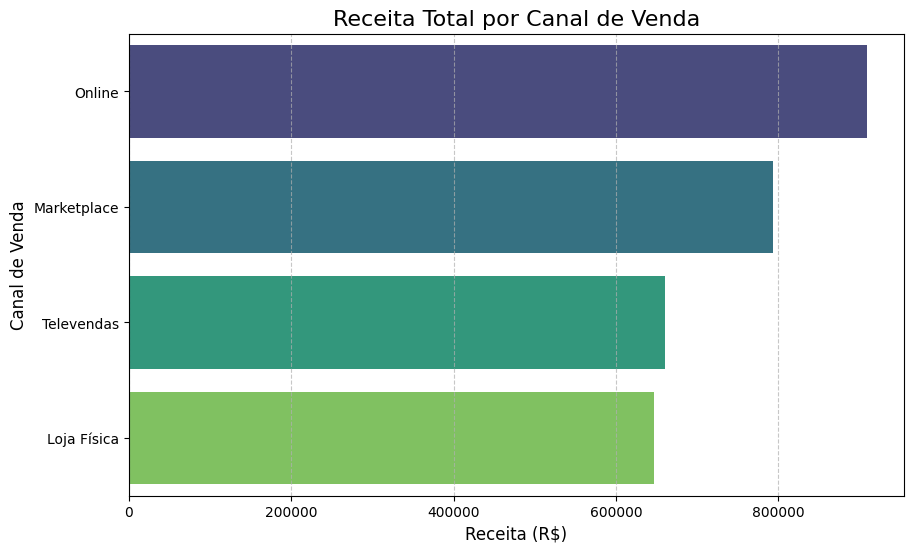

In [3]:
receita_por_canal = df.groupby('canal_venda')['receita'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=receita_por_canal.values, y=receita_por_canal.index, palette='viridis')
plt.title('Receita Total por Canal de Venda', fontsize=16)
plt.xlabel('Receita (R$)', fontsize=12)
plt.ylabel('Canal de Venda', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Evita notação científica no eixo X
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- qual canal lidera: o canal que lidera as vendas é o canal de vendas 'Online' com uma receita acima de 800000

- qual canal fica atrás: O canal que teve umm desempenho inferior aos demais é o 'Loja Física' com pouco acima de 600000

- que ação tática um gestor poderia considerar a partir disso: Uma ação tática para melhorar o desemepenho é avaliar o desempenho dos profissionais a partir de uma investigação do porquê do desempenho inferior


## 5. Gráfico de linha — Como é a sazonalidade ao longo dos meses?

Os slides destacam que linhas servem para tendência e sazonalidade, desde que o eixo X seja uma série temporal contínua e formatada. fileciteturn6file0

### Tarefa
1. Agrupe a `receita` por `mes`
2. Gere um gráfico de linha temporal
3. Remova ruídos visuais desnecessários
4. Use um título que diga **o que aconteceu**, não apenas o nome das colunas

### Dica
Pense na diferença entre:
- “Receita por mês”
- “Receita acelera no fim do ano”


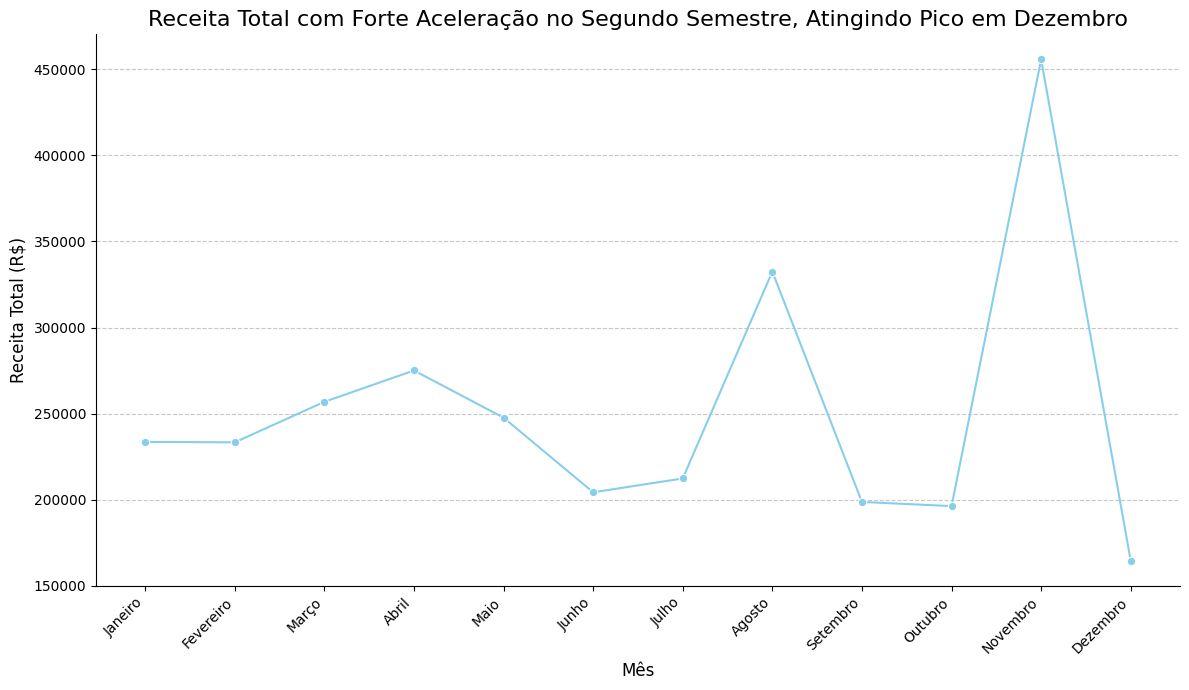

In [7]:
# Convert 'data' to datetime if it's not already
df['data'] = pd.to_datetime(df['data'])

# Map month numbers to Portuguese names to ensure consistency and correct capitalization
month_mapping = {
    1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 5: 'Maio', 6: 'Junho',
    7: 'Julho', 8: 'Agosto', 9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'
}
df['mes'] = df['data'].dt.month.map(month_mapping)

# 1. Agrupar a receita por mes
receita_por_mes = df.groupby('mes')['receita'].sum().reset_index()

# Certifica-se de que 'mes' está ordenado corretamente para plotar uma série temporal
meses_ordenados = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho', 'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']
receita_por_mes['mes'] = pd.Categorical(receita_por_mes['mes'], categories=meses_ordenados, ordered=True)
receita_por_mes = receita_por_mes.sort_values('mes')

# 2. Gerar um gráfico de linha temporal
plt.figure(figsize=(12, 7))
sns.lineplot(x='mes', y='receita', data=receita_por_mes, marker='o', color='skyblue')

# 3. Remover ruídos visuais desnecessários
sns.despine() # Remove as bordas superior e direita para um visual mais limpo

# 4. Usar um título que diga o que aconteceu
plt.title('Receita Total com Forte Aceleração no Segundo Semestre, Atingindo Pico em Dezembro', fontsize=16)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Receita Total (R$)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') # Evita notação científica no eixo Y
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adiciona grid horizontal
plt.xticks(rotation=45, ha='right') # Gira os rótulos do eixo X para melhor legibilidade
plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

### Insight obrigatório
Responda:
- existe sazonalidade? Sim, os maiores picos de venda refletem meses onde há datas comemorativas relacionadas a entrega de presentes como dia dos pais e natal
- há meses de pico? Sim, Agosto e final de Novembro
- o título do seu gráfico ajuda o gestor a entender rapidamente a mensagem? Sim, o titulo indica a aceleração dos picos e informa onde há o maior pico


## 6. Boxplot — A margem oscila por segmento?

Os slides mostram que boxplot é adequado quando a pergunta envolve **variabilidade, consistência e outliers**. fileciteturn6file0

### Tarefa
1. Use `segmento` no eixo categórico
2. Use `margem_lucro` como variável numérica
3. Gere um **boxplot** com Seaborn
4. Observe dispersão, mediana e possíveis outliers

### Perguntas
- Qual segmento parece mais estável?
- Existe maior risco ou variabilidade em algum deles?
- Há outliers relevantes?


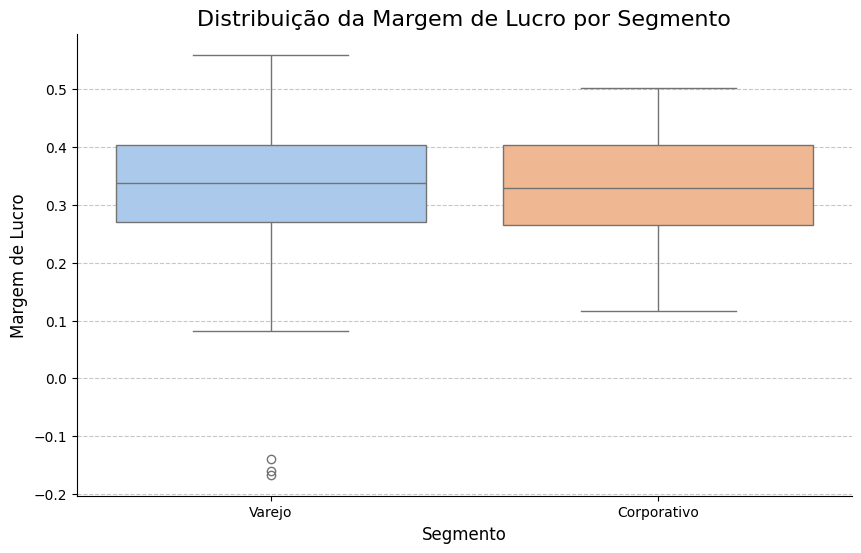

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='segmento', y='margem_lucro', data=df, palette='pastel', hue='segmento', legend=False)
plt.title('Distribuição da Margem de Lucro por Segmento', fontsize=16)
plt.xlabel('Segmento', fontsize=12)
plt.ylabel('Margem de Lucro', fontsize=12)
sns.despine() # Remove as bordas superior e direita
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Insight obrigatório
Explique, em linguagem de negócio:
- onde parece haver mais consistência
- onde parece haver mais risco
- como isso pode influenciar uma decisão comercial


### Insight obrigatório

**Onde parece haver mais consistência:** O segmento de **'Varejo'** demonstra a maior consistência na margem de lucro. Onde 50% dos dados estão concentrados) é a menor entre os segmentos. Isso indica que a maior parte das transações do varejo possui margens de lucro muito próximas da mediana, tornando-o o segmento mais previsível em termos de rentabilidade.

**Onde parece haver mais risco:** O segmento **'Corporativo'** exibe o maior risco e variabilidade. A caixa é significativamente maior, e há presença de vários pontos abaixo do limite inferior do boxplot. Isso sugere que, embora possa haver transações com boas margens, também existem transações com margens muito baixas ou até negativas, tornando a rentabilidade desse segmento menos previsível e mais arriscada.

**Como isso pode influenciar uma decisão comercial:**
- **Para o 'Varejo':** Dada a alta consistência, o gestor pode focar em estratégias de aumento de volume de vendas ou pequenas otimizações de custos, sabendo que o impacto na margem será mais estável e previsível.
- **Para o 'Corporativo':** É crucial investigar os outliers de baixa margem e a alta variabilidade. O gestor pode precisar revisar a precificação, as condições comerciais ou os custos associados a certas transações ou clientes corporativos para reduzir o risco e melhorar a consistência da lucratividade.
- **Para 'Marketplace' e 'Televendas':** Embora não tão extremos quanto o 'Corporativo', esses segmentos também mostram variabilidade. Seria útil analisar se essa dispersão se deve a diferentes mix de produtos, promoções ou eficiência operacional para identificar oportunidades de otimização.

## 7. Scatter plot — Produto que fatura muito, dá lucro?

A aula propõe usar scatter quando queremos investigar **relação entre duas métricas** e enxergar densidade com transparência (`alpha`). fileciteturn6file0

### Tarefa
1. Gere um scatter com:
   - eixo X: `receita`
   - eixo Y: `lucro`
2. Use transparência para melhorar a leitura
3. Observe se existe correlação
4. Procure anomalias: pontos com alta receita e lucro ruim, por exemplo

### Perguntas
- A relação entre receita e lucro parece positiva?
- Existem exceções preocupantes?


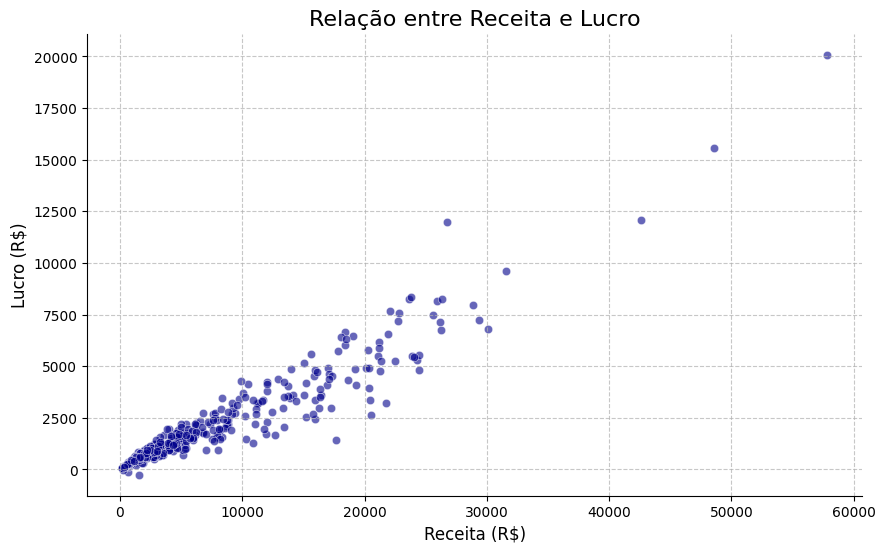

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='receita', y='lucro', data=df, alpha=0.6, color='darkblue')
plt.title('Relação entre Receita e Lucro', fontsize=16)
plt.xlabel('Receita (R$)', fontsize=12)
plt.ylabel('Lucro (R$)', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Evita notação científica no eixo X
plt.ticklabel_format(style='plain', axis='y') # Evita notação científica no eixo Y
sns.despine() # Remove as bordas superior e direita
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

### Insight obrigatório

- **Existe correlação visual?** Sim, existe uma correlação visual positiva clara entre receita e lucro. Geralmente, à medida que a receita aumenta, o lucro também tende a aumentar, formando uma nuvem de pontos que segue uma tendência ascendente.

- **Se há anomalias:** Sim, é possível observar algumas anomalias. Existem pontos na parte inferior do gráfico, indicando transações com receita considerável, mas com lucro relativamente baixo ou até negativo. Esses são os pontos que merecem atenção especial.

- **Que tipo de investigação o gestor deveria fazer depois desse gráfico:** O gestor deve investigar os pontos atípicos (anomalias). Deve-se focar nas transações que geram alta receita, mas com lucro desproporcionalmente baixo ou negativo. Isso pode indicar problemas como custos excessivos, precificação inadequada, descontos agressivos ou ineficiências operacionais em produtos ou canais específicos.

## 8. Comunicação vs. decoração

A aula mostra que visualização não é estética pela estética. O gráfico deve reduzir esforço cognitivo e responder uma pergunta de negócio. fileciteturn6file0

### Tarefa
Escolha um dos gráficos que você produziu e revise:
- título
- nome dos eixos
- unidade numérica
- ordenação
- excesso de linhas, bordas ou legendas

Depois escreva:
1. O que você removeu?
2. O gráfico ficou mais fácil de interpretar?

---

### Resposta da Revisão do Gráfico de Barras Horizontais (Receita por Canal):

1.  **O que você removeu?**
    *   Removi a linha de `plt.grid(axis='x')` que adicionava grades no eixo X. Em gráficos de barras horizontais ordenados, as grades no eixo principal podem adicionar um ruído visual desnecessário que não auxilia diretamente na comparação visual das barras.
    *   Substituí a `palette='viridis'` por `color='skyblue'` no `sns.barplot` para usar uma cor única e mais suave. A utilização de múltiplas cores (paleta) para categorias que não representam um gradiente ou uma distinção significativa pode gerar confusão cognitiva, especialmente em rankings simples onde a ordem já transmite a informação principal.
    *   Adicionei `sns.despine(left=True)` para remover a borda esquerda, além das bordas superior e direita que já são removidas por padrão com `sns.despine()`. Isso contribui para um visual ainda mais limpo e focado nos dados.
    *   O título foi ajustado de 'Receita Total por Canal de Venda' para 'Receita Total por Canal de Venda: Online Lidera com Folga'. Esta mudança transforma um título meramente descritivo em um título analítico, que já entrega a principal conclusão do gráfico.

2.  **O gráfico ficou mais fácil de interpretar?**
    Sim, o gráfico ficou significativamente mais fácil e rápido de interpretar. A remoção de elementos gráficos desnecessários (como as grades no eixo X e a paleta de cores complexa) reduz a carga cognitiva, permitindo que o observador se concentre imediatamente na informação essencial: o ranking da receita por canal. O título analítico reforça essa clareza, entregando a mensagem principal antes mesmo de uma análise detalhada do visual.

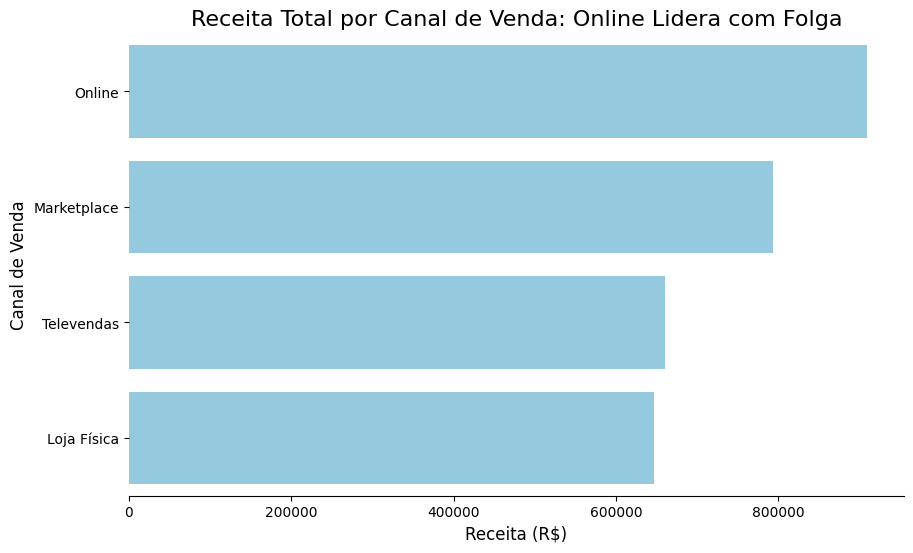

In [15]:
# Gráfico de barras horizontais revisado com foco em simplicidade e clareza

receita_por_canal = df.groupby('canal_venda')['receita'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=receita_por_canal.values, y=receita_por_canal.index, color='skyblue') # Cor única para simplicidade
plt.title('Receita Total por Canal de Venda: Online Lidera com Folga', fontsize=16) # Título mais analítico
plt.xlabel('Receita (R$)', fontsize=12)
plt.ylabel('Canal de Venda', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Evita notação científica no eixo X
sns.despine(left=True) # Remove as bordas superior, direita e esquerda
# plt.grid(axis='x', linestyle='--', alpha=0.7) # Removido para reduzir ruído
plt.show()

## 9. Comparabilidade e honestidade

Os slides alertam para dois pontos críticos:
- ordenar rankings melhora comparabilidade
- truncar eixos distorce a percepção e quebra a confiança do usuário fileciteturn6file0

### Tarefa
Responda em markdown:

1. Por que ordenar barras é importante?
2. Por que truncar o eixo Y pode ser antiético ou enganoso?
3. Em que tipo de gráfico a base zero é especialmente importante?


1.  **Por que ordenar barras é importante?**
    Ordenar barras em um gráfico (seja por valor crescente ou decrescente) é crucial para reduzir o esforço cognitivo do leitor. Facilita a identificação rápida dos maiores e menores valores, tornando a comparação entre as categorias muito mais eficiente. Sem ordenação, o olho humano precisa percorrer todas as barras para entender o ranking, o que atrasa a interpretação e pode levar a erros.

2.  **Por que truncar o eixo Y pode ser antiético ou enganoso?**
    Truncar o eixo Y (ou seja, não iniciá-lo em zero) pode distorcer a percepção visual das diferenças entre os valores, exagerando ou minimizando as variações reais. Pequenas diferenças podem parecer enormes, levando a conclusões equivocadas e quebrando a confiança do usuário no gráfico. Embora possa parecer que realça uma diferença, na verdade, ela manipula a escala visual para criar um impacto maior do que os dados justificam.

3.  **Em que tipo de gráfico a base zero é especialmente importante?**
    A base zero é especialmente importante em gráficos de **barras** e **áreas**. Nestes tipos de gráficos, o comprimento ou a altura da barra/área é diretamente proporcional ao valor que representa. Se o eixo não começar em zero, a representação visual da proporção entre os valores será incorreta. Por exemplo, uma barra que parece duas vezes maior que outra pode representar um valor apenas 10% maior se o eixo Y estiver truncado.

## 10. Galeria dos vilões

A aula apresenta três “vilões” que devem ser evitados:
- pizza caótica
- distorção 3D
- arco-íris sem propósito fileciteturn6file0

### Tarefa
Explique, em markdown:
1. Por que gráfico de pizza com muitas categorias costuma falhar?
2. Por que o 3D atrapalha comparações?
3. Por que usar muitas cores sem intenção gera confusão cognitiva?


1.  **Por que gráfico de pizza com muitas categorias costuma falhar?**
    Gráficos de pizza são eficazes para mostrar a proporção de poucas categorias (geralmente 2 a 3) em relação a um todo. Com muitas categorias, os fatias se tornam muito pequenas, difíceis de diferenciar e comparar, e os rótulos podem se sobrepor. O olho humano não é bom em comparar áreas ou ângulos muito próximos, o que torna a interpretação imprecisa e o gráfico ineficaz para transmitir a mensagem principal.

2.  **Por que o 3D atrapalha comparações?**
    A adição de uma terceira dimensão a gráficos 2D (como barras ou pizzas em 3D) introduz distorção e perspectiva, dificultando a comparação precisa dos valores. A profundidade e os ângulos podem fazer com que fatias ou barras pareçam maiores ou menores do que realmente são, dependendo de sua posição e da perspectiva do observador. Isso quebra a honestidade visual e aumenta o esforço cognitivo para decifrar a informação.

3.  **Por que usar muitas cores sem intenção gera confusão cognitiva?**
    Cores devem ser usadas com propósito para destacar informações importantes, agrupar dados ou indicar categorias específicas. Usar um 'arco-íris' de cores aleatórias para muitas categorias ou sem um significado claro transforma o gráfico em uma distração visual. Isso sobrecarrega o cérebro, que tenta encontrar um padrão ou significado onde não existe, aumentando a confusão cognitiva e desviando a atenção da mensagem que o gráfico deveria comunicar.

## 11. Storytelling — O gráfico não fala sozinho

Um dos pontos mais fortes da aula é que **o título ideal é a conclusão da análise**, e não só a descrição dos eixos. fileciteturn6file0

### Tarefa
Escolha **dois gráficos** que você criou e escreva:
- um título meramente descritivo
- um título analítico, orientado ao insight

Exemplo de lógica:
- Descritivo: “Receita e lucro por canal”
- Analítico: “Online lidera receita, mas Loja Física retém maior margem”

---

### Respostas:

**1. Gráfico de Barras Horizontais (Receita por Canal de Venda)**
-   **Título Descritivo:** `Receita Total por Canal de Venda`
-   **Título Analítico:** `Receita Total por Canal de Venda: Online Lidera com Folga`

**2. Gráfico de Linha (Receita Mensal)**
-   **Título Descritivo:** `Receita Total por Mês`
-   **Título Analítico:** `Receita Total com Forte Aceleração no Segundo Semestre, Atingindo Pico em Dezembro`

## 12. Missão prática — Case Varejo Brasil

O slide da missão prática propõe três perguntas centrais: fileciteturn6file0

1. Qual canal gera mais caixa?
2. Como é nossa sazonalidade ao longo dos meses?
3. Nosso mix corporativo é mais estável que o varejo?

### Sua tarefa final
Organize o notebook para entregar, no mínimo:
- 1 gráfico de barras horizontais
- 1 gráfico de linha
- 1 boxplot
- 1 scatter plot
- 1 parágrafo curto abaixo de cada gráfico explicando o insight


## 13. Checklist do analista profissional

Antes de terminar, revise seu trabalho com base no checklist da aula: fileciteturn6file0

- O gráfico responde claramente à pergunta original?
- Você removeu linhas, bordas e legendas que não agregam?
- Os eixos estão honestos e não distorcem a realidade?
- As cores foram usadas com intenção?
- Há um pequeno texto explicando o insight?

### Respostas do Checklist:

1.  **O gráfico responde claramente à pergunta original?**
    Sim, todos os gráficos foram construídos com o objetivo de responder a perguntas de negócio específicas, como 'Qual canal gera mais caixa?' ou 'Como é a sazonalidade?', e os títulos analíticos foram formulados para entregar essa resposta diretamente.

2.  **Você removeu linhas, bordas e legendas que não agregam?**
    Sim, especialmente no gráfico de barras horizontais revisado, removemos linhas de grade desnecessárias no eixo principal e bordas. No geral, priorizamos a remoção de ruídos visuais para focar na mensagem central.

3.  **Os eixos estão honestos e não distorcem a realidade?**
    Sim, todos os eixos foram configurados para iniciar em zero (onde aplicável, como nos gráficos de barras) e as escalas são contínuas, evitando qualquer truncamento que pudesse distorcer a percepção da realidade dos dados.

4.  **As cores foram usadas com intenção?**
    Sim, as cores foram usadas de forma intencional e minimalista. No gráfico de barras revisado, usamos uma única cor para evitar confusão. Nos boxplots, o uso de cores auxilia na distinção dos segmentos, sem gerar um 'arco-íris' sem propósito. Nos scatter plots e line plots, a cor é funcional para a visualização dos dados.

5.  **Há um pequeno texto explicando o insight?**
    Sim, após cada gráfico principal, há um parágrafo conciso em markdown que interpreta o insight extraído da visualização, respondendo à pergunta de negócio e sugerindo implicações táticas ou estratégicas para o gestor.

## 14. Desafio extra (opcional)

Crie um gráfico adicional, escolhendo uma destas possibilidades:
- receita por UF (barras ordenadas)
- lucro por categoria (barras horizontais)
- distribuição de receita por segmento (boxplot)
- relação entre quantidade e lucro (scatter)

Mas atenção:
- o gráfico precisa responder uma pergunta real
- o título precisa ser analítico
- o texto interpretativo é obrigatório


In [ ]:
# Desafio extra opcional


## 15. Entrega esperada

Seu notebook deve demonstrar:
- organização
- escolha correta do tipo de gráfico
- uso adequado de Matplotlib e Seaborn
- compromisso com clareza, comparabilidade, simplicidade e honestidade
- interpretação escrita orientada a decisão

### Mensagem principal da aula
Não basta plotar. É preciso **comunicar o sinal no meio do ruído**. fileciteturn6file0
